 <p style="font-family:Bookman Old Style;font-size:27px; text-align:center">Frequency domain Gaussian blur filter with scipy
 signal.fftconvolve()</p>

<div style="margin:0 130px 0 30px;text-align:justify"><p style="font-family:Source Sans Pro;font-size:20px">The following code block shows how the SciPy signal module's fftconvolve() function can be used to run the convolution in the frequency domain</p></div>

<p style="font-family:Bookman Old Style;font-size:27px">Import libraries</p>

In [17]:
import cv2
import numpy as np
import scipy.fftpack as fp
from scipy import signal
import matplotlib.pyplot as plt

<p style="font-family:Bookman Old Style;font-size:27px">Loading and Preprocessing the Image</p>

In [18]:
img = cv2.imread('../images-videos/lenna.jpg')
img_gry = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

<p style="font-family:Bookman Old Style;font-size:27px">Defining the Gaussian Kernel Generator</p>

In [19]:
def make_gaussian_kernel(w, h, std):
    v_kernel = signal.windows.gaussian(h, std)
    h_kernel = signal.windows.gaussian(w, std)
    kernel = np.outer(v_kernel, h_kernel)
    return kernel

<p style="font-family:Bookman Old Style;font-size:27px">Creating Gaussian Kernels</p>

In [20]:
k1 = make_gaussian_kernel(11, 11, 3)
k2 = make_gaussian_kernel(50, 50, 10)

<p style="font-family:Bookman Old Style;font-size:27px">Applying Gaussian Blur Using FFT Convolution</p>

In [21]:
blurred_img_1 = signal.fftconvolve(img_gry, k1, mode='same')
blurred_img_2 = signal.fftconvolve(img_gry, k2, mode='same')

<p style="font-family:Bookman Old Style;font-size:27px">Visualizing Gaussian Blur Results</p>

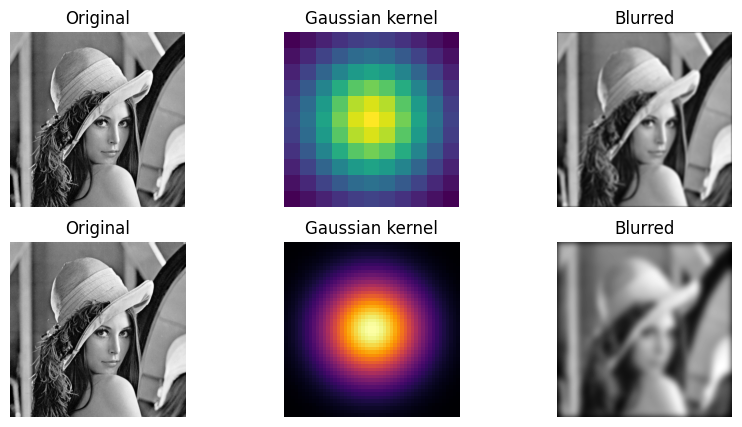

In [22]:
plt.figure(figsize=(10, 5))

plt.subplot(231)
plt.imshow(img_gry, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(232)
plt.imshow(k1)
plt.title('Gaussian kernel')
plt.axis('off')

plt.subplot(233)
plt.imshow(blurred_img_1, cmap='gray')
plt.title('Blurred')
plt.axis('off')

plt.subplot(234)
plt.imshow(img_gry, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(235)
plt.imshow(k2, cmap='inferno')
plt.title('Gaussian kernel')
plt.axis('off')

plt.subplot(236)
plt.imshow(blurred_img_2, cmap='gray')
plt.title('Blurred')
plt.axis('off')

plt.show()

<p style="font-family:Bookman Old Style;font-size:27px">Computing the Fourier Transform</p>

In [23]:
F = fp.fftshift(fp.fft2(img_gry))
mag_F = 20 * np.log10(np.abs(F) + 0.01)

F1 = fp.fftshift(fp.fft2(blurred_img_1))
mag_F1 = 20 * np.log10(np.abs(F1) + 0.01)

F2 = fp.fftshift(fp.fft2(blurred_img_1))
mag_F2 = 20 * np.log10(np.abs(F2) + 0.01)

<p style="font-family:Bookman Old Style;font-size:27px">Visualizing Frequency Spectrum</p>

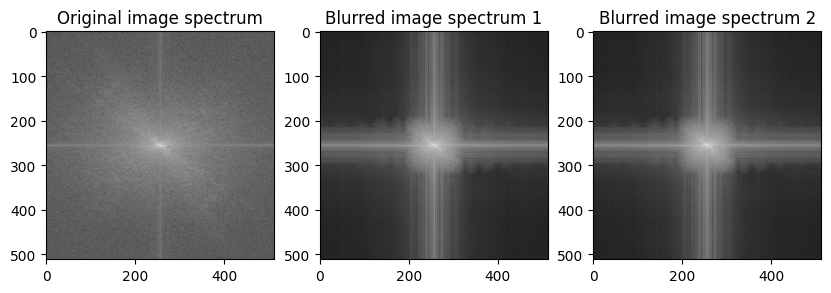

In [24]:
plt.figure(figsize=(10, 5))

plt.subplot(131)
plt.imshow(mag_F, cmap='gray')
plt.title('Original image spectrum')

plt.subplot(132)
plt.imshow(mag_F1, cmap='gray')
plt.title('Blurred image spectrum 1')

plt.subplot(133)
plt.imshow(mag_F2, cmap='gray')
plt.title('Blurred image spectrum 2')

plt.show()